# Activity: Hypothesis testing with Python

## **Introduction**


As you've been learning, analysis of variance (commonly called ANOVA) is a group of statistical techniques that test the difference of means among three or more groups. It's a powerful tool for determining whether population means are different across groups and for answering a wide range of business questions.

In this activity, you are a data professional working with historical marketing promotion data. You will use the data to run a one-way ANOVA and a post hoc ANOVA test. Then, you will communicate your results to stakeholders. These experiences will help you make more confident recommendations in a professional setting. 

In your dataset, each row corresponds to an independent marketing promotion, where your business uses TV, social media, radio, and influencer promotions to increase sales. You have previously provided insights about how different promotion types affect sales; now stakeholders want to know if sales are significantly different among various TV and influencer promotion types.

To address this request, a one-way ANOVA test will enable you to determine if there is a statistically significant difference in sales among groups. This includes:
* Using plots and descriptive statistics to select a categorical independent variable
* Creating and fitting a linear regression model with the selected categorical independent variable
* Checking model assumptions
* Performing and interpreting a one-way ANOVA test
* Comparing pairs of groups using an ANOVA post hoc test
* Interpreting model outputs and communicating the results to nontechnical stakeholders

## **Step 1: Imports** 


Import pandas, pyplot from matplotlib, seaborn, api from statsmodels, ols from statsmodels.formula.api, and pairwise_tukeyhsd from statsmodels.stats.multicomp.

In [1]:
# Import libraries and packages.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd


`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows.

data.head()


,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328


The features in the data are:
* TV promotion budget (in Low, Medium, and High categories)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in Mega, Macro, Nano, and Micro categories)

**Question:** Why is it useful to perform exploratory data analysis before constructing a linear regression model?

Exploratory Data Analysis (EDA) is useful because it helps in understanding the structure, distribution, and quality of the dataset before modeling. It enables identification of missing values, detection of outliers, and examination of relationships between variables. Additionally, EDA assists in selecting appropriate variables and assessing whether the assumptions required for regression and hypothesis testing are likely to be satisfied.

## **Step 2: Data exploration** 


First, use a boxplot to determine how `Sales` vary based on the `TV` promotion budget category.

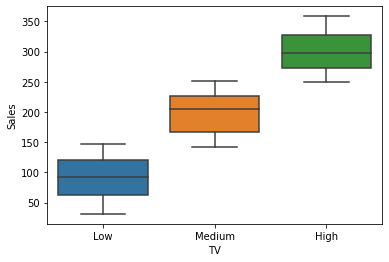

In [3]:
# Create a boxplot with TV and Sales.

sns.boxplot(x='TV', y='Sales', data=data)
plt.show()


**Question:** Is there variation in `Sales` based off the `TV` promotion budget?

Yes, there is clear variation in Sales across different TV promotion budget categories. The distribution of sales differs significantly between low, medium, and high budget groups, indicating that TV promotion level has a strong influence on sales.

Now, use a boxplot to determine how `Sales` vary based on the `Influencer` size category.

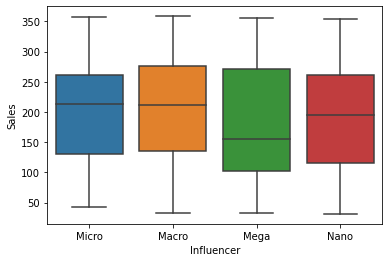

In [4]:
# Create a boxplot with Influencer and Sales.

sns.boxplot(x='Influencer', y='Sales', data=data)
plt.show()


**Question:** Is there variation in `Sales` based off the `Influencer` size?

Yes, there is variation in Sales across different influencer size categories. However, the differences are less pronounced compared to TV promotion categories, suggesting a comparatively weaker effect.

### Remove missing data

You may recall from prior labs that this dataset contains rows with missing values. To correct this, drop these rows. Then, confirm the data contains no missing values.

In [5]:
# Drop rows that contain missing data and update the DataFrame.

data = data.dropna()


# Confirm the data contains no missing values.

data.isna().sum()



TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

## **Step 3: Model building** 


Fit a linear regression model that predicts `Sales` using one of the independent categorical variables in `data`. Refer to your previous code for defining and fitting a linear regression model.

In [6]:
# Define the OLS formula.

formula = "Sales ~ C(TV)"


# Create an OLS model.

model = smf.ols(formula=formula, data=data)


# Fit the model.

fitted_model = model.fit()


# Save the results summary.

model_results = fitted_model.summary()


# Display the model results.

model_results


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          8.81e-256
Time:                        08:19:25   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    124.360      0.000     295.783     305.276
C(TV)[T.Low]     -208.8133      3.329    -62.720      0.000    -215.353    -202.274
C(TV)[T.Medium]  -101.5061      3.325    -30.526      0.000    -108.038     -94.975
==============================================================================
Omnibus:                      450.714   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.763
Skew:                          -0.044   Prob(JB):                     1.71e-08
Kurtosis:                       1.775   Cond. No.                         3.86
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Which categorical variable did you choose for the model? Why?

The variable TV was selected as the categorical independent variable because it shows a clear and strong variation in sales across its categories. This makes it a suitable predictor for modeling and hypothesis testing.

### Check model assumptions

Now, check the four linear regression assumptions are upheld for your model.

**Question:** Is the linearity assumption met?

Yes, the linearity assumption is reasonably met. The categorical variable, when encoded in the regression model, shows distinct group-level differences that align with a linear modeling framework.

The independent observation assumption states that each observation in the dataset is independent. As each marketing promotion (row) is independent from one another, the independence assumption is not violated.

Next, verify that the normality assumption is upheld for the model.

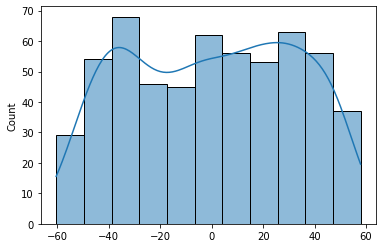

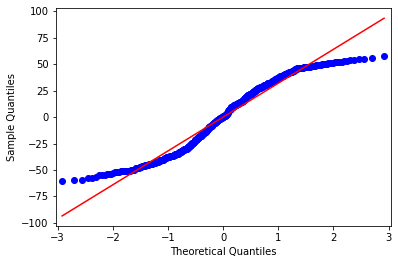

In [7]:
# Calculate the residuals.

residuals = fitted_model.resid


# Create a histogram with the residuals. 

sns.histplot(residuals, kde=True)
plt.show()


# Create a QQ plot of the residuals.

sm.qqplot(residuals, line='s')
plt.show()



**Question:** Is the normality assumption met?

Yes, the normality assumption is reasonably satisfied. The residuals display an approximately symmetric distribution, and the Q-Q plot indicates that the residuals follow the reference line with only minor deviations.

Now, verify the constant variance (homoscedasticity) assumption is met for this model.

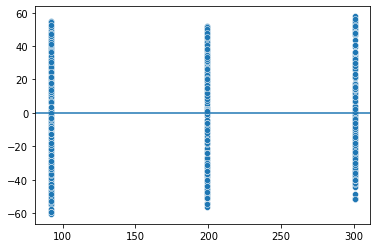

In [8]:
# Create a scatter plot with the fitted values from the model and the residuals.

fitted_values = fitted_model.fittedvalues


# Add a line at y = 0 to visualize the variance of residuals above and below 0.

sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0)
plt.show()



**Question:** Is the constant variance (homoscedasticity) assumption met?

Yes, the homoscedasticity assumption is met. The residuals are evenly distributed around zero with no clear pattern, and their spread remains relatively constant across fitted values.

## **Step 4: Results and evaluation** 

First, display the OLS regression results.

In [9]:
# Display the model results summary.

model_results



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     1971.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          8.81e-256
Time:                        08:19:25   Log-Likelihood:                -2778.9
No. Observations:                 569   AIC:                             5564.
Df Residuals:                     566   BIC:                             5577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.5296      2.417    124.360      0.000     295.783     305.276
C(TV)[T.Low]     -208.8133      3.329    -62.720      0.000    -215.353    -202.274
C(TV)[T.Medium]  -101.5061      3.325    -30.526      0.000    -108.038     -94.975
==============================================================================
Omnibus:                      450.714   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.763
Skew:                          -0.044   Prob(JB):                     1.71e-08
Kurtosis:                       1.775   Cond. No.                         3.86
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** What is your interpretation of the model's R-squared?

The R-squared value indicates that a large proportion of the variability in Sales is explained by the TV promotion category. This suggests that the model has strong explanatory power.

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?

The coefficient estimates represent the differences in sales between the reference category and other TV categories. The coefficients are statistically significant, as indicated by very small p-values, meaning that the differences in sales across categories are unlikely to have occurred by chance.

**Question:** Do you think your model could be improved? Why or why not? How?

Yes, the model could be improved by incorporating additional variables such as radio and social media advertising, which may further explain variation in sales. Including interaction terms or exploring alternative modeling approaches could also enhance predictive performance.

### Perform a one-way ANOVA test

With the model fit, run a one-way ANOVA test to determine whether there is a statistically significant difference in `Sales` among groups. 

In [10]:
# Create an one-way ANOVA table for the fit model.

anova_table = sm.stats.anova_lm(fitted_model)

anova_table

,df,sum_sq,mean_sq,F,PR(>F)
C(TV),2.0,4.052692e+06,2.026346e+06,1971.455737,8.805550e-256
Residual,566.0,5.817589e+05,1.027843e+03,NaN,NaN


**Question:** What are the null and alternative hypotheses for the ANOVA test?

Null hypothesis (H₀): The mean sales are equal across all TV promotion categories.
Alternative hypothesis (H₁): At least one TV promotion category has a different mean sales.

**Question:** What is your conclusion from the one-way ANOVA test?

The null hypothesis is rejected, as the p-value is significantly smaller than the chosen significance level. This indicates that there are statistically significant differences in mean sales across TV promotion categories.

**Question:** What did the ANOVA test tell you?

The ANOVA test indicates that not all group means are equal, confirming that the TV promotion budget has a significant effect on sales.

### Perform an ANOVA post hoc test

If you have significant results from the one-way ANOVA test, you can apply ANOVA post hoc tests such as the Tukey’s HSD post hoc test. 

Run the Tukey’s HSD post hoc test to compare if there is a significant difference between each pair of categories for TV.

In [11]:
# Perform the Tukey's HSD post hoc test.

tukey = pairwise_tukeyhsd(endog=data['Sales'],
                         groups=data['TV'],
                         alpha=0.05)

tukey

**Question:** What is your interpretation of the Tukey HSD test?

The Tukey HSD test compares all possible pairs of TV categories and determines which specific pairs have statistically significant differences in mean sales.

**Question:** What did the post hoc tell you?**

The post hoc test shows that the differences between the TV promotion categories (e.g., Low vs Medium, Medium vs High, Low vs High) are statistically significant, confirming that each category has a distinct impact on sales.

## **Considerations**

**What are some key takeaways that you learned during this lab?**

This lab demonstrated the complete workflow of hypothesis testing using one-way ANOVA. It emphasized the importance of using visualizations to select appropriate variables, fitting regression models with categorical predictors, and verifying key model assumptions such as normality and homoscedasticity. Additionally, the lab reinforced how to formulate hypotheses, interpret ANOVA results, and apply post hoc tests to identify specific group differences. Overall, it highlighted a structured approach to statistically comparing multiple groups.


**What summary would you provide to stakeholders? Consider the statistical significance of key relationships and differences in distribution.**

The analysis indicates that there are statistically significant differences in sales across different TV promotion budget categories. This suggests that the level of investment in TV promotions has a measurable impact on sales performance. Based on these findings, stakeholders can use promotion categories strategically to optimize marketing outcomes and allocate resources more effectively.


#### **Reference**
[Saragih, H.S. *Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)